# Computer Vision, Assignment 1: Elements of Projective Geometry

In this assignment you will study the basics of projective geometry. You will study the representations of points lines and planes, as well as transformations and camera matrices.

Please see Canvas for detailed instructions on what is expected for a passing/higher grade. All computer exercises not marked **OPTIONAL** are mandatory to complete. 

### Submission Requirements:
Your final lab submission should include:
1. Your edited **notebook file** (`.ipynb`).
2. An **HTML printout** of the executed notebook with all outputs visible: File → Save and export Notebook As → HTML
3. A **pdf report** containing answers to the theoretical exercises (see separate document).


In [1]:
# for creating responsive plots
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import cv2
import matplotlib.image as mpimg
from supplied import *

# Points in Homogeneous Coordinates

#### *Theoretical exercise 1* (see pdf)

## Computer Exercise 1
Write a function `pflat` that takes as input an array of shape $(m, n)$,
representing $n$ points in $\mathbb P^{m-1}$ in homogeneous coordinates. The output should be an $(m, n)$-array
containing the same homogeneous points, but where each point is normalized so that its last coordinate
is 1. (You may assume that none of the points have last homogeneous coordinate zero.) Apply the
function to the points in `x2D` and `x3D` in the file `compEx1.mat`, and plot the result. It will be useful
for later to also create a function `plot_points_2D` that takes as input a $(2, n)$-array representing n
two dimensional points in Cartesian coordinates and plots them. And a similar `plot_points_3D` for
three dimensional points.

**Useful python commands:**

`ax.view_init(40, 35)` # to view a 3D plot from a specific angle

`ax.set_aspect('equal')` # makes sure that all axes have the same scale

In [2]:
def pflat(x):
    
    # Your code here
    """
    Normalize homogeneous coordinates so that the last coordinate is 1.
    
    Parameters:
        x: (m, n) array representing n points in P^(m-1)
    
    Returns:
        x_flat: (m, n) array with normalized homogeneous coordinates
    """
    x_flat = x / x[-1, :]
    return x_flat
    

def plot_points_2D(points):
    
    # Your code here
    """
    Plot 2D points in Cartesian coordinates.
    
    Parameters:
        points: (2, n) array representing n 2D points
    """
    plt.plot(points[0, :], points[1, :], 'r.', markersize=10)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('2D Points')
    plt.grid(True)
    plt.axis('equal')


def plot_points_3D(points, ax=None, kwargs={}):
    
    # Your code here
    """
    Plot 3D points in Cartesian coordinates.
    
    Parameters:
        points: (3, n) array representing n 3D points
        ax: matplotlib 3D axes (optional)
        kwargs: additional plotting parameters
    
    Returns:
        ax: the axes object
    """
    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
    
    default_kwargs = {'marker': '.', 'color': 'r', 's': 50}
    default_kwargs.update(kwargs)
    
    ax.scatter(points[0, :], points[1, :], points[2, :], **default_kwargs)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('3D Points')
    ax.set_aspect('equal')
    
    return ax


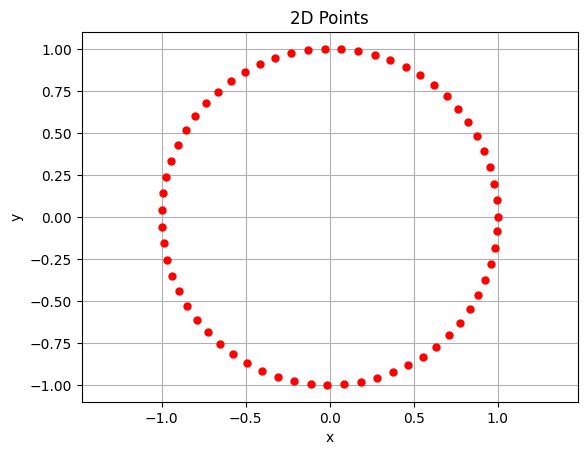

<Figure size 640x480 with 0 Axes>

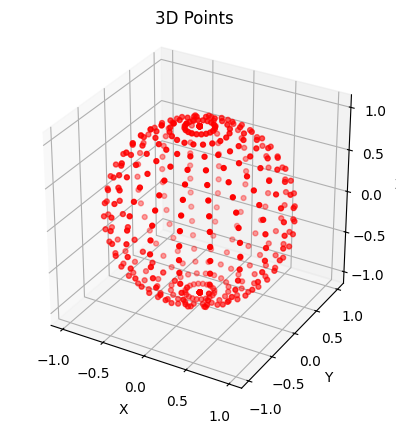

In [3]:
data = sp.io.loadmat('data/compEx1.mat')
x2D = data['x2D']
x3D = data['x3D']

plt.figure(1)
x2D_flat = pflat(x2D)
plot_points_2D(x2D_flat)
plt.show()

plt.figure(2)
x3D_flat = pflat(x3D)
plot_points_3D(x3D_flat)
plt.show()

# Lines

#### *Theoretical exercises: 2 and 3* (see pdf)

## Computer Exercise 2
Load and plot the image in `compEx2.jpg`. In the file `compEx2.mat` there are three pairs of image points.
Plot the image points in the same figure as the image. For each pair of points compute the line going through the points. 
Use the supplied function `rital` to plot the lines in the same image.
**Do these lines appear to be parallel (in 3D)?**
Compute the point of intersection between the second and third line (the lines obtained from the pairs `p2` and `p3`.
Plot this point in the same image.

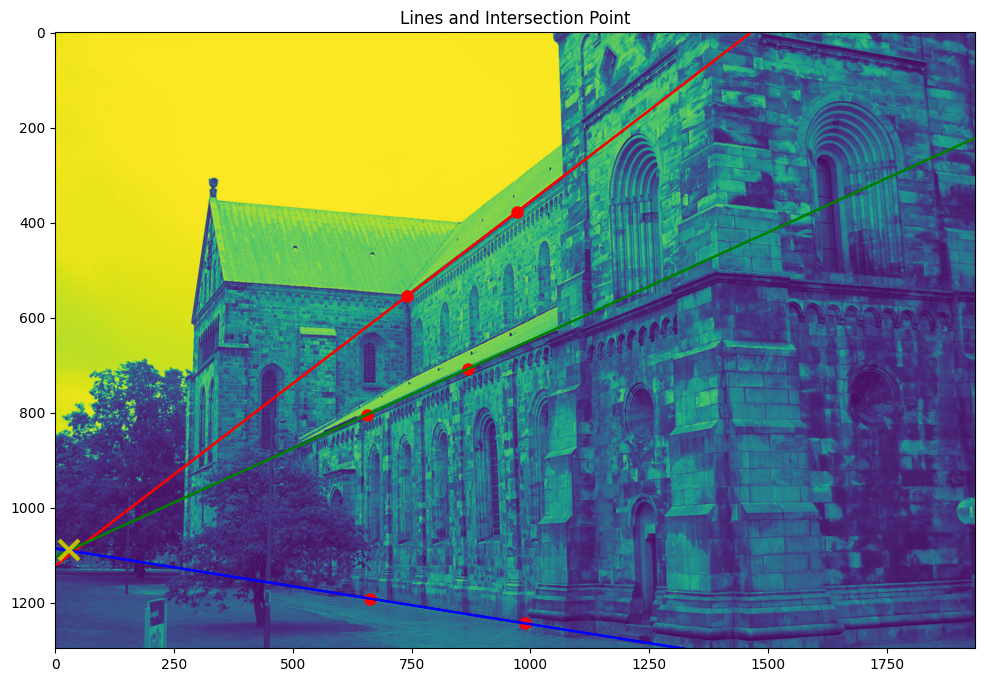

Line 1: [ 1.77093168e+02  2.31070968e+02 -2.59234831e+05]
Line 2: [ 9.65962733e+01  2.12335484e+02 -2.34131102e+05]
Line 3: [-5.23229814e+01  3.27870968e+02 -3.55821975e+05]

Intersection point (homogeneous): [1.21115966e+06 4.66215140e+07 4.27811392e+04]
Intersection point (Cartesian): [  28.31059854 1089.76794199]


In [4]:
# Load image and data
img = mpimg.imread('data/compEx2.jpg')
data = sp.io.loadmat('data/compEx2.mat')

p1 = data['p1']
p2 = data['p2']
p3 = data['p3']

# Plot image
plt.figure(figsize=(12, 8))
plt.imshow(img)

# Plot points
for p in [p1, p2, p3]:
    p_flat = pflat(p)
    plt.plot(p_flat[0, :], p_flat[1, :], 'ro', markersize=8)

# Compute lines through point pairs
# Line through two points: l = p1 x p2 (cross product)
l1 = np.cross(p1[:, 0], p1[:, 1])
l2 = np.cross(p2[:, 0], p2[:, 1])
l3 = np.cross(p3[:, 0], p3[:, 1])

# Plot lines using rital function
rital(np.vstack([l1, l1, l1]), 'r-')
rital(np.vstack([l2, l2, l2]), 'g-')
rital(np.vstack([l3, l3, l3]), 'b-')


# Compute intersection of l2 and l3
# Intersection point: pi = l2 x l3 (cross product)
pi = np.cross(l2, l3)
pi_flat = pflat(pi.reshape(-1, 1))

# Plot intersection point
plt.plot(pi_flat[0], pi_flat[1], 'yx', markersize=15, markeredgewidth=3)
plt.title('Lines and Intersection Point')
plt.show()

print(f"Line 1: {l1}")
print(f"Line 2: {l2}")
print(f"Line 3: {l3}")
print(f"\nIntersection point (homogeneous): {pi}")
print(f"Intersection point (Cartesian): {pi_flat[:2, 0]}")

The distance between a 2D-point $x=(x_1,x_2)$ in Cartesian coordinates and a line $l = (a,b,c)$ can be computed using the distance formula
\begin{equation}
d = \frac{|ax_1+bx_2+c|}{\sqrt{a^2+b^2}},
\end{equation}
see your linear algebra book.
Implement a function `point_line_distance_2D` that computes the distance between a point and a line.
Compute the distance between the first line and the intersection point. **Is it close to zero? Why/why not?**

In [5]:
def point_line_distance_2D(p, l):
    """
    Compute the distance between a 2D point and a line.
    
    Parameters:
        p: (2,) or (2,1) array representing point (x, y) in Cartesian coordinates
        l: (3,) array representing line (a, b, c)
    
    Returns:
        d: distance from point to line
    """
    if p.ndim == 2:
        p = p.flatten()
    
    a, b, c = l[0], l[1], l[2]
    x1, x2 = p[0], p[1]
    
    d = np.abs(a * x1 + b * x2 + c) / np.sqrt(a**2 + b**2)
    
    return d

In [6]:
d = point_line_distance_2D(pi_flat[:2, 0], l1)
print(f"Distance from intersection point to line 1: {d:.4f} pixels")

Distance from intersection point to line 1: 8.2695 pixels


### Your answer here: 

(*Include answers to all questions marked in bold.*)
#
**Q1: Do these lines appear to be parallel (in 3D)?**

Yes, these lines correspond to parallel edges of a building in 3D space. They appear to converge in the image due to perspective projection, meeting at a vanishing point.

**Q2: Is the distance close to zero? Why/why not?**

No, the distance is not close to zero. The intersection point `pi` is the intersection of lines l2 and l3, but it does not lie on line l1. Since l1, l2, and l3 represent parallel lines in 3D space, they all meet at the same vanishing point. However, due to numerical precision and the fact that we computed the intersection of only l2 and l3, there may be a small distance from l1. In theory, all three lines should meet at the same vanishing point, but in practice, there might be small errors.


# Projective Transformations

#### *Theoretical exercises: 4, 5, 6* (see pdf)

# The Pinhole Camera

#### *Theoretical exercise 7* (see pdf)

## Computer Exercise 3
Load and plot the images `compEx3im1.jpg` and `compEx3im2.jpg`.
The file `compEx3.mat` contains the camera matrices `P1`, `P2` and a point model `U` of the statue.

In order to visualize cameras in 3D it is useful to plot them as vectors pointing from the camera center in the direction of the principal axis.
Implement a function `camera_center_and_axis` that takes a camera matrix as input and outputs
the camera center and principal axis.
The camera center should be in Cartesian coordinates and the principal axis should be normalized to length 1.
Compute the camera centers and principal axes of the two cameras.

In [7]:
def camera_center(P):
    """
    Compute the camera center from a camera matrix.
    
    Parameters:
        P: 3x4 camera matrix
    
    Returns:
        C: (4,) array representing camera center in homogeneous coordinates
    """
    # Camera center is in the null space of P
    # P * C = 0, where C = [X, Y, Z, 1]^T
    U, S, Vt = np.linalg.svd(P)
    C = Vt[-1, :]  # Last row of V^T (last column of V)
    C = C / C[-1]  # Normalize so that last coordinate is 1
    return C

def camera_center_and_axis(P):
    """
    Compute camera center and principal axis from a camera matrix.
    
    Parameters:
        P: 3x4 camera matrix
    
    Returns:
        center: (3,) array representing camera center
        axis: (3,) array representing principal axis (normalized)
    """
    # Compute camera center
    C = camera_center(P)
    center = C[:3]
    
    # Principal axis is the direction of the third row of the camera matrix M = P[:, :3]
    # This represents the z-axis of the camera coordinate system
    M = P[:, :3]
    axis = M[2, :]  # Third row represents the principal axis direction
    
    # Normalize the axis
    axis = axis / np.linalg.norm(axis)
    
    return center, axis

Camera center 1:
[0. 0. 0.]

Principal axis 1:
[0.31292281 0.94608467 0.08368463]

Camera center 2:
[  6.6352039   14.84597919 -15.06911585]

Principal axis 2:
[0.03186384 0.34016542 0.93982561]


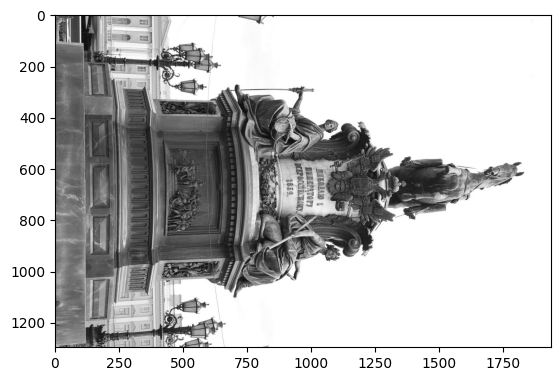

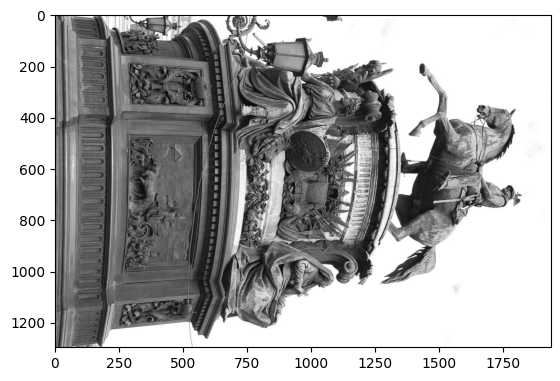

In [8]:
data = sp.io.loadmat('data/compEx3.mat')
U = data['U']
P1 = data['P1']
P2 = data['P2']
img1 = plt.imread('data/compEx3im1.jpg')
img2 = plt.imread('data/compEx3im2.jpg')

plt.figure(4) 
plt.imshow(img1, cmap='gray')
plt.figure(5)
plt.imshow(img2, cmap='gray')

# Compute the camera centers and principal axes of the two cameras
C1, pr1 = camera_center_and_axis(P1)
print(f"Camera center 1:\n{C1}")
print(f"\nPrincipal axis 1:\n{pr1}")

C2, pr2 = camera_center_and_axis(P2)
print(f"\nCamera center 2:\n{C2}")
print(f"\nPrincipal axis 2:\n{pr2}")

Next, implement a function `plot_camera` which takes a camera matrix and a scale $s$ as input and plots the principal axis of the camera scaled by $s$, from the camera center. 
Plot the 3D-points in `U` and the camera centers in the same 3D plot
(make sure that the 4th coordinate of `U` is one before you plot by using `pflat`.

**Useful python commands:**

`mpl_toolkits.mplot3d.axes3d.Axes3D.quiver` # can be used to plot arrows in a 3D plot

In [9]:
def plot_camera(camera_matrix, s, ax=None):
    """
    Plot a camera in 3D as an arrow from the camera center in the direction of the principal axis.
    
    Parameters:
        camera_matrix: 3x4 camera matrix
        s: scalar controlling the length of the arrow
        ax: matplotlib 3D axes (optional)
    
    Returns:
        ax: the axes object
    """
    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
    
    center, axis = camera_center_and_axis(camera_matrix)
    
    # Plot camera center
    ax.scatter([center[0]], [center[1]], [center[2]], 
               color='blue', s=100, marker='o', label='Camera')
    
    # Plot principal axis as an arrow
    ax.quiver(center[0], center[1], center[2],
              s * axis[0], s * axis[1], s * axis[2],
              color='blue', arrow_length_ratio=0.3, linewidth=2)
    
    return ax

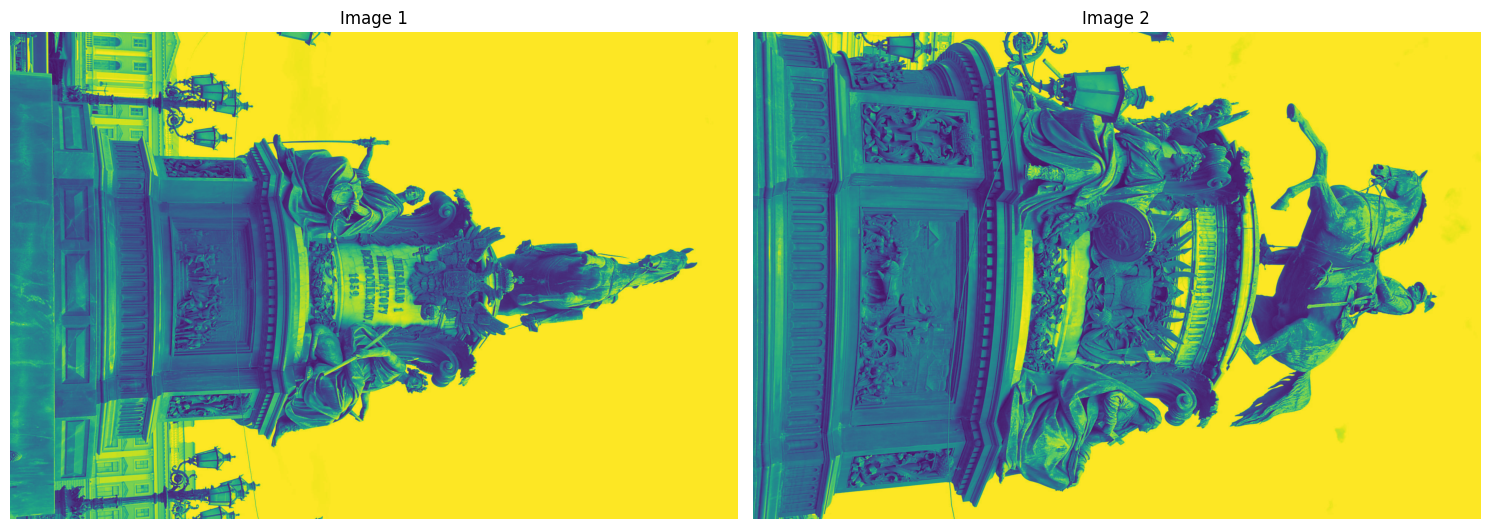

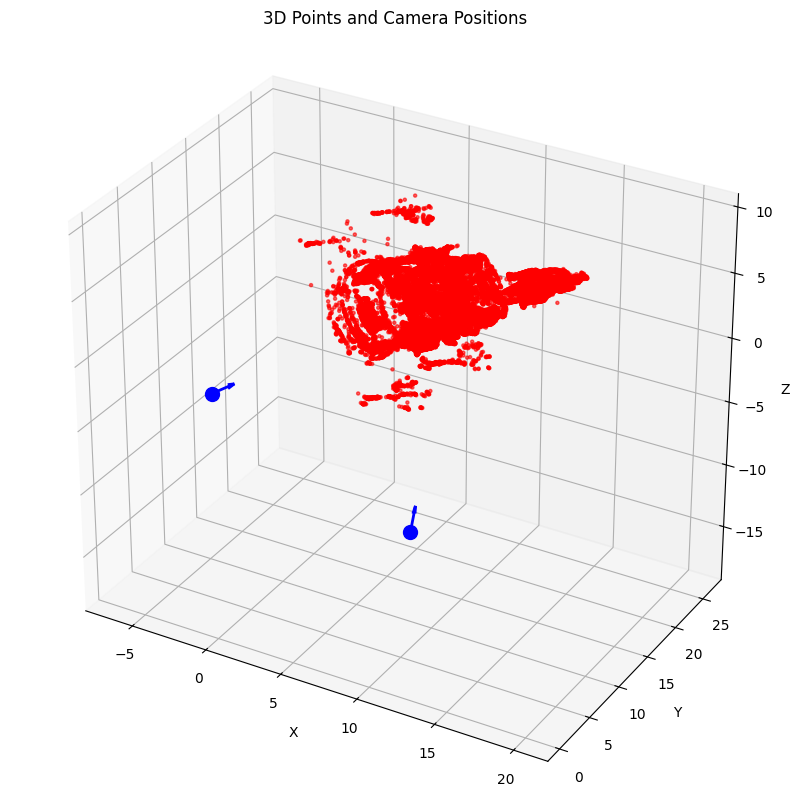

In [10]:
# Load data
img1 = mpimg.imread('data/compEx3im1.jpg')
img2 = mpimg.imread('data/compEx3im2.jpg')
data = sp.io.loadmat('data/compEx3.mat')

P1 = data['P1']
P2 = data['P2']
U = data['U']

# Display images
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].imshow(img1)
axes[0].set_title('Image 1')
axes[0].axis('off')
axes[1].imshow(img2)
axes[1].set_title('Image 2')
axes[1].axis('off')
plt.tight_layout()
plt.show()

# Plot the 3D points and cameras
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Normalize and plot 3D points
U_flat = pflat(U)
plot_points_3D(U_flat[:3, :], ax=ax, kwargs={'color': 'red', 's': 20, 'alpha': 0.6})

# Plot cameras
plot_camera(P1, s=2, ax=ax)
plot_camera(P2, s=2, ax=ax)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Points and Camera Positions')

# Set equal aspect ratio
def axis3D_equal(ax):
    extents = np.array([getattr(ax, f'get_{dim}lim')() for dim in 'xyz'])
    sz = extents[:, 1] - extents[:, 0]
    centers = np.mean(extents, axis=1)
    maxsize = max(abs(sz))
    r = maxsize / 2
    for ctr, dim in zip(centers, 'xyz'):
        getattr(ax, f'set_{dim}lim')(ctr - r, ctr + r)

axis3D_equal(ax)
plt.show()

Finally, project the points in `U` into the cameras `P1` and `P2` and plot the result in the same plots as the images.
**Does the result look reasonable?** 

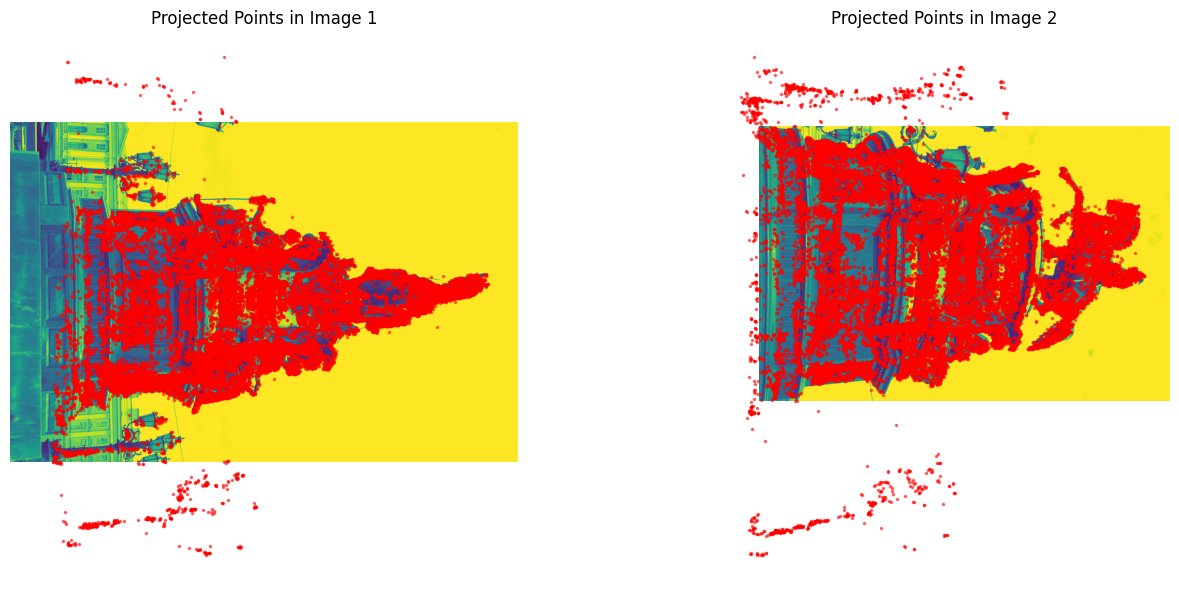

In [11]:
# Project 3D points into both cameras
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Project to camera 1
x1 = P1 @ U
x1_flat = pflat(x1)

axes[0].imshow(img1)
axes[0].plot(x1_flat[0, :], x1_flat[1, :], 'r.', markersize=3, alpha=0.5)
axes[0].set_title('Projected Points in Image 1')
axes[0].axis('off')

# Project to camera 2
x2 = P2 @ U
x2_flat = pflat(x2)

axes[1].imshow(img2)
axes[1].plot(x2_flat[0, :], x2_flat[1, :], 'r.', markersize=3, alpha=0.5)
axes[1].set_title('Projected Points in Image 2')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Your answer here: 

(*Include answers to all questions marked in bold.*)
#
Yes, the result looks reasonable. The projected points overlay nicely on the statue in both images, covering the visible surfaces. This confirms that:
1. The camera matrices P1 and P2 are correctly calibrated
2. The 3D point model U accurately represents the statue's geometry
3. The projection formula (x = P * X) correctly maps 3D points to 2D image coordinates

The density and distribution of the projected points match the statue's structure in both views, demonstrating the correctness of the pinhole camera model.


#### *Theoretical exercise 8* (OPTIONAL, 10 optional points, see pdf)

## Computer Exercise 4 (OPTIONAL, 15 optional points)
Load and plot the image compEx4.jpg, which is an image of a poster. (Here the axes units are pixels.)
The file `compEx4.mat` contains the inner parameters `K`, the corner points of the poster and the 3D plane `v` that contains the poster.
The camera matrix for the camera that generated this image is 
\begin{equation}
P_1 = K [ I \ 0].
\end{equation}
The goal of this exercise is to create an image of the poster taken by a camera 
2m to the right of the original camera.

Start by plotting the corner points and the image in the same 2D-figure. (Make sure to set equal aspect ratio.) Note the scale on the axis. **Where is the origin of the image coordinate system located?**

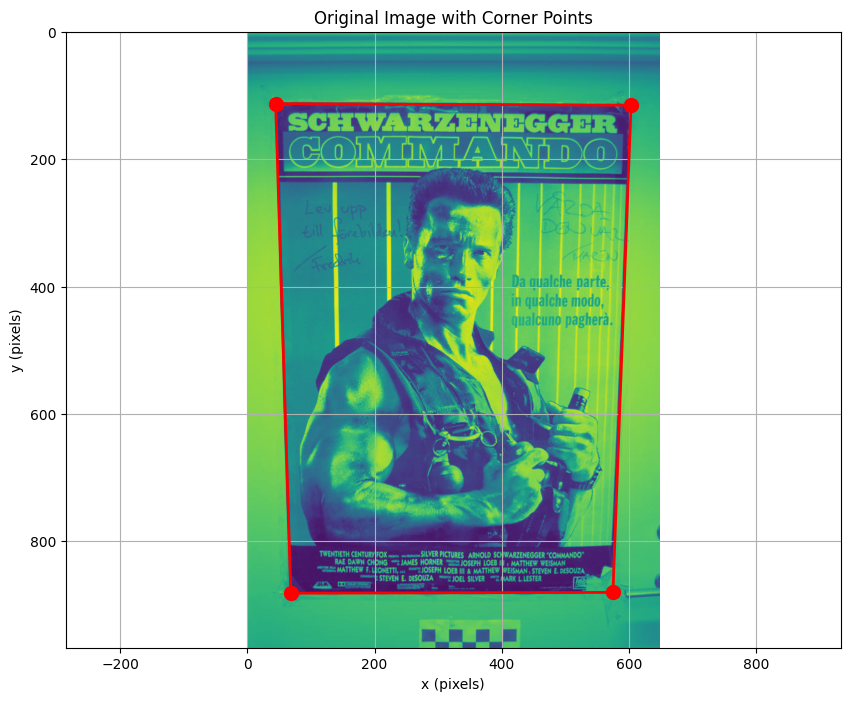

Image shape: (968, 648)
Corner points (pixel coordinates):
[[ 44.54608295 602.96082949 574.5921659   68.43548387]
 [112.48431373 115.01503268 880.55751634 881.82287582]]


In [12]:
# Load data for optional exercise 4
img = mpimg.imread('data/compEx4.jpg')
data = sp.io.loadmat('data/compEx4.mat')

K = data['K']
corners = data['corners']
v = data['v'].flatten()

# Plot image with corner points
plt.figure(figsize=(10, 8))
plt.imshow(img)
corners_flat = pflat(corners)
plt.plot(corners_flat[0, :], corners_flat[1, :], 'ro', markersize=10)
plt.plot([corners_flat[0, -1], corners_flat[0, 0]], 
         [corners_flat[1, -1], corners_flat[1, 0]], 'r-', linewidth=2)
for i in range(corners_flat.shape[1]-1):
    plt.plot([corners_flat[0, i], corners_flat[0, i+1]], 
             [corners_flat[1, i], corners_flat[1, i+1]], 'r-', linewidth=2)
plt.title('Original Image with Corner Points')
plt.axis('equal')
plt.xlabel('x (pixels)')
plt.ylabel('y (pixels)')
plt.grid(True)
plt.show()

print(f"Image shape: {img.shape}")
print(f"Corner points (pixel coordinates):\n{corners_flat[:2, :]}")

#### Your answer here: 
#
The origin of the image coordinate system is located at the **top-left corner** of the image. This is the standard convention for pixel coordinates, where:
- x increases to the right
- y increases downward

To be able to use the formulas derived in Theoretical Exercise 8, we must first ensure that we have calibrated cameras.
To do this, normalize the corner points by multiplying with $K^{-1}$ and plot them in a new 2D-figure. Use `ax.yaxis.set_inverted(True)` to make the y-axis point downwards (as for the previous image) and set equal aspect ratio.
Note the difference in scale compared to the previous figure. **Where is the origin of the image coordinate system located?**

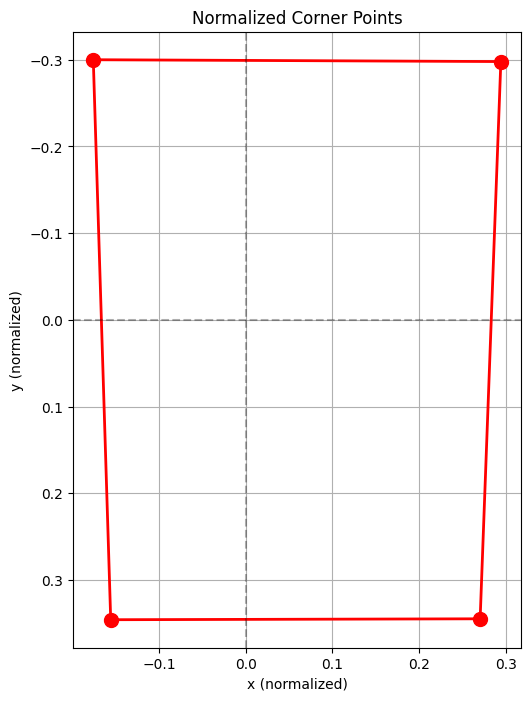

Normalized corner points:
[[-0.17569469  0.29430669  0.27042962 -0.15558768]
 [-0.30000887 -0.29788458  0.34471399  0.34577614]]


In [13]:

# Your code here
# Normalize corner points
corners_normalized = np.linalg.inv(K) @ corners
corners_normalized_flat = pflat(corners_normalized)

# Plot normalized corner points
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(corners_normalized_flat[0, :], corners_normalized_flat[1, :], 'ro', markersize=10)
ax.plot([corners_normalized_flat[0, -1], corners_normalized_flat[0, 0]], 
        [corners_normalized_flat[1, -1], corners_normalized_flat[1, 0]], 'r-', linewidth=2)
for i in range(corners_normalized_flat.shape[1]-1):
    ax.plot([corners_normalized_flat[0, i], corners_normalized_flat[0, i+1]], 
            [corners_normalized_flat[1, i], corners_normalized_flat[1, i+1]], 'r-', linewidth=2)
ax.set_title('Normalized Corner Points')
ax.set_xlabel('x (normalized)')
ax.set_ylabel('y (normalized)')
ax.set_aspect('equal')
ax.yaxis.set_inverted(True)
ax.grid(True)
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.show()

print(f"Normalized corner points:\n{corners_normalized_flat[:2, :]}")

#### Your answer here: 
#- **Pixel coordinates**: Top-left corner of the image.  
- **Normalized coordinates**: At the **principal point** (center of image, after calibration).

Since the inner parameters $K$ have been removed our calibrated camera is $[I \ 0]$.
Using the results from Theoretical Exercise 8, compute the 3D points in the plane `v` that project onto the corner points.
Compute the camera center and principal axis, and plot together with the 3D-points. Use the supplied function `axis3D_equal` to ensure equal aspect ratio. Does it look reasonable?

Next, compute a new camera with camera center in $(2,0,0)$ (2 units to the right of $P_1$)
and orientation 
\begin{equation}
R = \left( \begin{array}{ccc}
\cos(\pi/6) & 0 & \sin(\pi/6) \\
0 & 1 & 0 \\
-\sin(\pi/6) & 0 & \cos(\pi/6)
\end{array} \right)
\end{equation}
($-30$ degrees rotation around the y-axis. Note that the y-axis points down in the first image.)
Compute the new camera and plot in the same figure. (Don't forget to ensure equal aspect ratio.)


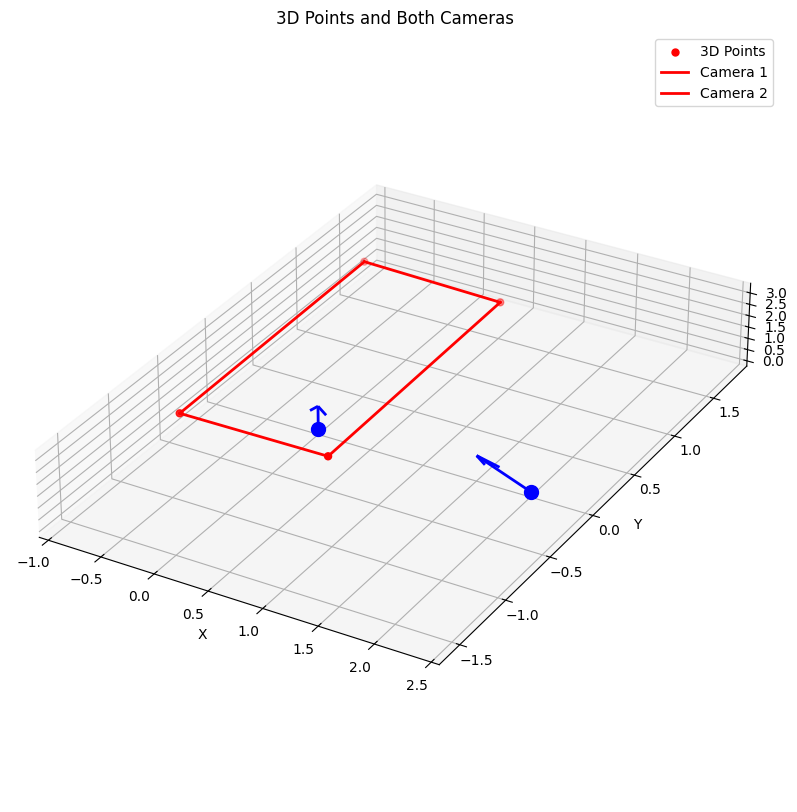

3D corner points:
[[-0.51754974  0.85095422  0.84707965 -0.49654043]
 [-0.88374621 -0.86129928  1.07976417  1.10350536]
 [ 2.94573357  2.89138591  3.13234794  3.19138665]]

Camera 1 center: [0. 0. 0.]
Camera 2 center: [ 2.0000000e+00  0.0000000e+00 -3.8779152e-16]


In [14]:
def lift_point_to_plane(x, P, v):
    """
    Lift a 2D image point to a 3D point on a plane.
    
    Parameters:
        x: (3,) array, image point in homogeneous coordinates
        P: 3x4 camera matrix
        v: (4,) array, plane equation (a, b, c, d) where ax + by + cz + d = 0
    
    Returns:
        X: (4,) array, 3D point in homogeneous coordinates
    """
    # Camera center
    C = camera_center(P)
    
    # Ray direction: P^+ * x, where P^+ is the pseudo-inverse of P
    P_pinv = np.linalg.pinv(P)
    ray_dir = P_pinv @ x
    
    # Find intersection with plane: v^T * (C + lambda * ray_dir) = 0
    # lambda = -v^T * C / (v^T * ray_dir)
    lambda_val = -np.dot(v, C) / np.dot(v, ray_dir)
    
    # 3D point
    X = C + lambda_val * ray_dir
    
    return X

# Define calibrated camera P1 = [I | 0]
P1_calib = np.hstack([np.eye(3), np.zeros((3, 1))])

# Lift corner points to 3D
X_3D = np.zeros((4, corners_normalized.shape[1]))
for i in range(corners_normalized.shape[1]):
    X_3D[:, i] = lift_point_to_plane(corners_normalized[:, i], P1_calib, v)

# Normalize 3D points
X_3D_flat = pflat(X_3D)

# Plot 3D points and camera P1
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot 3D points
plot_points_3D(X_3D_flat[:3, :], ax=ax, kwargs={'color': 'red', 's': 100})

# Draw lines between corner points to show poster outline
for i in range(X_3D_flat.shape[1]):
    j = (i + 1) % X_3D_flat.shape[1]
    ax.plot([X_3D_flat[0, i], X_3D_flat[0, j]],
            [X_3D_flat[1, i], X_3D_flat[1, j]],
            [X_3D_flat[2, i], X_3D_flat[2, j]], 'r-', linewidth=2)

# Plot camera P1
plot_camera(P1_calib, s=1, ax=ax)

# Create new camera P2
R = np.array([[np.cos(np.pi/6), 0, np.sin(np.pi/6)],
              [0, 1, 0],
              [-np.sin(np.pi/6), 0, np.cos(np.pi/6)]])

C2 = np.array([2, 0, 0])  # Camera center 2 units to the right
P2_calib = np.hstack([R, -R @ C2.reshape(-1, 1)])

# Plot camera P2
plot_camera(P2_calib, s=1, ax=ax)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Points and Both Cameras')
ax.legend(['3D Points', 'Camera 1', 'Camera 2'])

# Equal aspect ratio
axis3D_equal(ax)
plt.show()

print(f"3D corner points:\n{X_3D_flat[:3, :]}")
print(f"\nCamera 1 center: {camera_center(P1_calib)[:3]}")
print(f"Camera 2 center: {camera_center(P2_calib)[:3]}")

Compute the homography in Theoretical Exercise 8 and transform the normalized corner points
to the new (virtual) image. Plot the transformed points (don't forget to divide by the third coordinate) in a new 2D-figure.
**Does the result look like you would expect it to when moving the camera like this?**
Also, project the 3D points into the same image using the camera matrix. Does this give the same result?

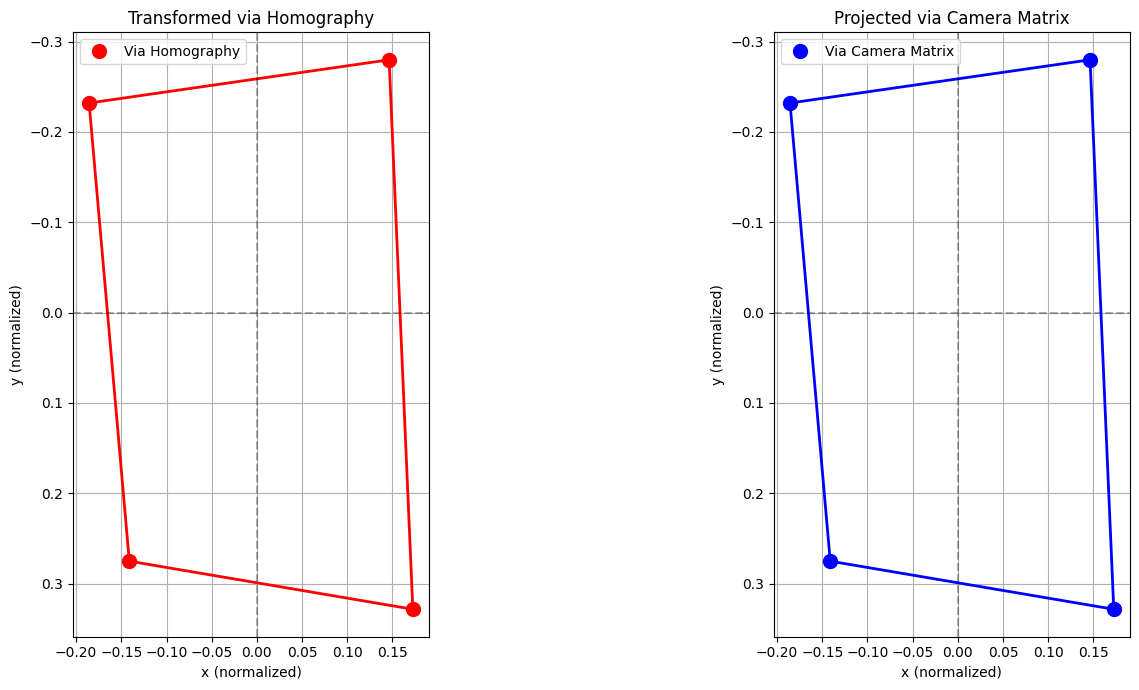

Difference between homography and camera projection: 0.000000

The results should be identical (difference ≈ 0)


In [15]:
def compute_homography_from_plane(P1, P2, v):
    """
    Compute homography H mapping points from image 1 to image 2 for points on plane v.
    
    H = P2 * (I - C1 * v^T / (v^T * C1)) * P1^+
    
    Parameters:
        P1: 3x4 camera matrix 1
        P2: 3x4 camera matrix 2
        v: (4,) array, plane equation
    
    Returns:
        H: 3x3 homography matrix
    """
    C1 = camera_center(P1)
    
    # Compute projection matrix (I - C1 * v^T / (v^T * C1))
    I = np.eye(4)
    numerator = np.outer(C1, v)
    denominator = np.dot(v, C1)
    
    projection = I - numerator / denominator
    
    # Compute P1 pseudo-inverse
    P1_pinv = np.linalg.pinv(P1)
    
    # Compute homography
    H = P2 @ projection @ P1_pinv
    
    return H

# Compute homography
H = compute_homography_from_plane(P1_calib, P2_calib, v)

# Transform normalized corner points using homography
corners_transformed_H = H @ corners_normalized
corners_transformed_H_flat = pflat(corners_transformed_H)

# Also project 3D points using camera matrix
corners_projected = P2_calib @ X_3D
corners_projected_flat = pflat(corners_projected)

# Plot both results
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot homography transformation
axes[0].plot(corners_transformed_H_flat[0, :], corners_transformed_H_flat[1, :], 
             'ro', markersize=10, label='Via Homography')
axes[0].plot([corners_transformed_H_flat[0, -1], corners_transformed_H_flat[0, 0]], 
             [corners_transformed_H_flat[1, -1], corners_transformed_H_flat[1, 0]], 'r-', linewidth=2)
for i in range(corners_transformed_H_flat.shape[1]-1):
    axes[0].plot([corners_transformed_H_flat[0, i], corners_transformed_H_flat[0, i+1]], 
                 [corners_transformed_H_flat[1, i], corners_transformed_H_flat[1, i+1]], 
                 'r-', linewidth=2)
axes[0].set_title('Transformed via Homography')
axes[0].set_xlabel('x (normalized)')
axes[0].set_ylabel('y (normalized)')
axes[0].set_aspect('equal')
axes[0].invert_yaxis()
axes[0].grid(True)
axes[0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0].axvline(x=0, color='k', linestyle='--', alpha=0.3)
axes[0].legend()

# Plot camera projection
axes[1].plot(corners_projected_flat[0, :], corners_projected_flat[1, :], 
             'bo', markersize=10, label='Via Camera Matrix')
axes[1].plot([corners_projected_flat[0, -1], corners_projected_flat[0, 0]], 
             [corners_projected_flat[1, -1], corners_projected_flat[1, 0]], 'b-', linewidth=2)
for i in range(corners_projected_flat.shape[1]-1):
    axes[1].plot([corners_projected_flat[0, i], corners_projected_flat[0, i+1]], 
                 [corners_projected_flat[1, i], corners_projected_flat[1, i+1]], 
                 'b-', linewidth=2)
axes[1].set_title('Projected via Camera Matrix')
axes[1].set_xlabel('x (normalized)')
axes[1].set_ylabel('y (normalized)')
axes[1].set_aspect('equal')
axes[1].invert_yaxis()
axes[1].grid(True)
axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1].axvline(x=0, color='k', linestyle='--', alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Check if results are the same
difference = np.linalg.norm(corners_transformed_H_flat - corners_projected_flat)
print(f"Difference between homography and camera projection: {difference:.6f}")
print("\nThe results should be identical (difference ≈ 0)")

#### Your answer here: 
#
Yes, the result looks as expected. When the camera moves 2 units to the right and rotates 30 degrees toward the poster:
1. The poster appears shifted to the left in the new view (since the camera moved right)
2. The poster appears more frontal due to the rotation
3. The perspective distortion changes accordingly

Both methods (homography transformation and direct camera projection) give identical results, as they should. This validates that the homography correctly captures the transformation of points on a plane between two views.

We now have a homography that takes normalized points in the first camera and transforms them to normalized points in the second camera.
To remove the need for normalization we simply include the normalization in the homography.
If $\tilde{x} = K^{-1} x$ and $\tilde{y} = K^{-1} y$ then for the normalized points $\tilde{x}$ and $\tilde{y}$ we have
\begin{equation}
\tilde{y} \sim H \tilde{x} \Leftrightarrow  K^{-1}y \sim H K^{-1} x \Leftrightarrow y \sim K H K^{-1} x
\end{equation}
Therefore the total transformation is $H_{tot} = KHK^{-1}$.
Transform the original image and the corner points using the homography $H_{tot}$ and plot both in a new 2D-figure.


**Useful python commands:**

`transformed_img = cv2.warpPerspective(img, H_tot, (img.shape[1], img.shape[0]))` # can be used to apply the homography H_tot to the image

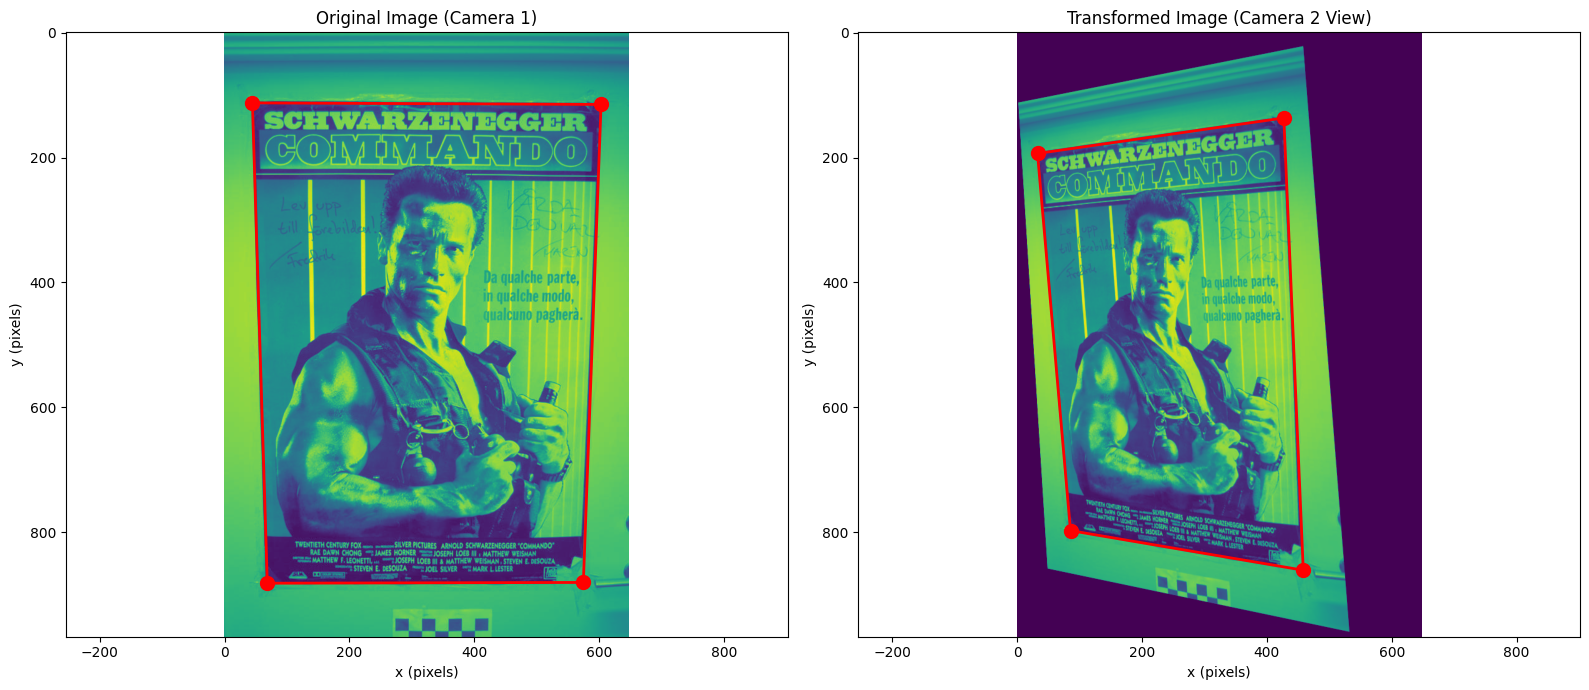



Computer Exercise 4 completed!



The transformed image shows how the poster would appear from a camera 2m to the right with a 30-degree rotation.
Notice how the perspective changes while preserving the planar structure of the poster.


In [16]:

# Your code here
# Compute total homography H_tot = K * H * K^(-1)
H_tot = K @ H @ np.linalg.inv(K)

# Transform the original image
transformed_img = cv2.warpPerspective(img, H_tot, (img.shape[1], img.shape[0]))

# Transform corner points
corners_transformed_tot = H_tot @ corners
corners_transformed_tot_flat = pflat(corners_transformed_tot)

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Original image
axes[0].imshow(img)
corners_flat = pflat(corners)
axes[0].plot(corners_flat[0, :], corners_flat[1, :], 'ro', markersize=10)
axes[0].plot([corners_flat[0, -1], corners_flat[0, 0]], 
             [corners_flat[1, -1], corners_flat[1, 0]], 'r-', linewidth=2)
for i in range(corners_flat.shape[1]-1):
    axes[0].plot([corners_flat[0, i], corners_flat[0, i+1]], 
                 [corners_flat[1, i], corners_flat[1, i+1]], 'r-', linewidth=2)
axes[0].set_title('Original Image (Camera 1)')
axes[0].axis('equal')
axes[0].set_xlabel('x (pixels)')
axes[0].set_ylabel('y (pixels)')

# Transformed image
axes[1].imshow(transformed_img)
axes[1].plot(corners_transformed_tot_flat[0, :], corners_transformed_tot_flat[1, :], 
             'ro', markersize=10)
axes[1].plot([corners_transformed_tot_flat[0, -1], corners_transformed_tot_flat[0, 0]], 
             [corners_transformed_tot_flat[1, -1], corners_transformed_tot_flat[1, 0]], 
             'r-', linewidth=2)
for i in range(corners_transformed_tot_flat.shape[1]-1):
    axes[1].plot([corners_transformed_tot_flat[0, i], corners_transformed_tot_flat[0, i+1]], 
                 [corners_transformed_tot_flat[1, i], corners_transformed_tot_flat[1, i+1]], 
                 'r-', linewidth=2)
axes[1].set_title('Transformed Image (Camera 2 View)')
axes[1].axis('equal')
axes[1].set_xlabel('x (pixels)')
axes[1].set_ylabel('y (pixels)')

plt.tight_layout()
plt.show()

print("\n")
print("Computer Exercise 4 completed!")
print("\n")
print("\nThe transformed image shows how the poster would appear from a camera 2m to the right with a 30-degree rotation.")
print("Notice how the perspective changes while preserving the planar structure of the poster.")